# Notebook 0: How the 300 texts were chosen

This notebook tests no hypothesis. It shows how the texts were picked and split into three groups,
because every later result depends on these choices.

**In short**
1. Start from 1,200 texts that each have the author's own emotion and 5 readers' emotions.
2. Drop texts labelled *boredom* or *no-emotion* (not among the 11 emotions).
3. **Unambiguous** = at least 4 of 5 readers agree *and* agree with the author.
4. For the rest: if two personas in a pilot test gave different emotions → **author-relevant**,
   otherwise → **author-independent**.
5. Keep 100 texts per group.

**All code is in this notebook.** Read the text cells first; the code can be skipped on a first read.

In [1]:
# ---- Setup: libraries, folders, the rule's settings and plot style (all defined here) ----
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# The project folder is the one that contains data/.
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
BASE = ROOT / 'data'
CORPUS = BASE / 'corpus'

# The rule's settings. The same values are in scripts/classify_ambiguity_pools.py, the script
# that originally built the sample.
THRESHOLD = 0.8                        # at least 4 of 5 readers must agree
SEED = 42                              # fixed random seed for trimming/replacing texts
OFF_LABELS = {'boredom', 'no-emotion'} # labels outside the 11 emotions
EXAMPLE_IDS = {468, 393, 417}          # texts used as prompt examples, never sampled

CATEGORY_EMOTIONS = ('anger', 'disgust', 'fear', 'guilt', 'joy', 'pride',
                     'relief', 'sadness', 'shame', 'surprise', 'trust')
CATEGORY_LABELS = ['Unambiguous', 'Author-Independent Ambiguous', 'Author-Relevant Ambiguous']
COLORS = {'Unambiguous': '#4C72B0', 'Author-Independent Ambiguous': '#DD8452',
          'Author-Relevant Ambiguous': '#C44E52', 'human': '#4C72B0', 'llm': '#DD8452'}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11.5, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'axes.labelsize': 11.5, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
                     'grid.linestyle': '-', 'legend.frameon': False, 'figure.facecolor': 'white',
                     'axes.facecolor': 'white'})
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

print(f"THRESHOLD = {THRESHOLD}   SEED = {SEED}")
print(f"Excluded labels: {sorted(OFF_LABELS)}")
print(f"Reserved prompt-example texts (never sampled): {sorted(EXAMPLE_IDS)}")

THRESHOLD = 0.8   SEED = 42
Excluded labels: ['boredom', 'no-emotion']
Reserved prompt-example texts (never sampled): [393, 417, 468]


## 1. The corpus

crowd-enVent (Troiano et al., 2023): short descriptions of emotional experiences. For 1,200 of them
there are **two layers**: the emotion the author says they felt, and the emotion each of 5
independent readers picked (the readers never saw the author's answer). That makes it possible to
measure disagreement between author and readers, and among readers.

In [2]:
gen = pd.read_csv(CORPUS / 'crowd-enVent_generation.tsv', sep='\t')
val = pd.read_csv(CORPUS / 'crowd-enVent_validation.tsv', sep='\t')

texts = gen[['text_id', 'generated_text', 'emotion']].rename(
    columns={'generated_text': 'text', 'emotion': 'author_emotion'})
readers = val[['text_id', 'emotion']].rename(columns={'emotion': 'reader_emotion'})

print(f"generation rows : {len(gen):,}  ({texts['text_id'].nunique():,} unique texts)")
print(f"validation rows : {len(val):,}")
rpt = readers.groupby('text_id').size()
print(f"readers per text: {rpt.value_counts().to_dict()}")
print()
print("The validation layer covers a 1,200-text subset at exactly 5 readers each, which is the")
print("pool this study samples from. Five is simply the number of independent judgments this")
print("corpus provides per text; disagreement is observable with as few as two. What five buys is")
print("resolution -- it distinguishes unanimity, a 4-1 split, a 3-2 split and a tie, which is the")
print("granularity the ambiguity threshold in Section 3 relies on.")


generation rows : 6,600  (6,600 unique texts)
validation rows : 6,000
readers per text: {5: 1200}

The validation layer covers a 1,200-text subset at exactly 5 readers each, which is the
pool this study samples from. Five is simply the number of independent judgments this
corpus provides per text; disagreement is observable with as few as two. What five buys is
resolution -- it distinguishes unanimity, a 4-1 split, a 3-2 split and a tie, which is the
granularity the ambiguity threshold in Section 3 relies on.


Annotated candidate pool: 1,200 texts
Columns: ['text_id', 'batch', 'persona_a', 'persona_b', 'rationale', 'judge_a', 'judge_b', 'text', 'author_emotion', 'reader_majority', 'majority_share', 'author_matches_readers', 'flip', 'new_classification']
Text length: median 13 words, IQR [8, 25], max 203


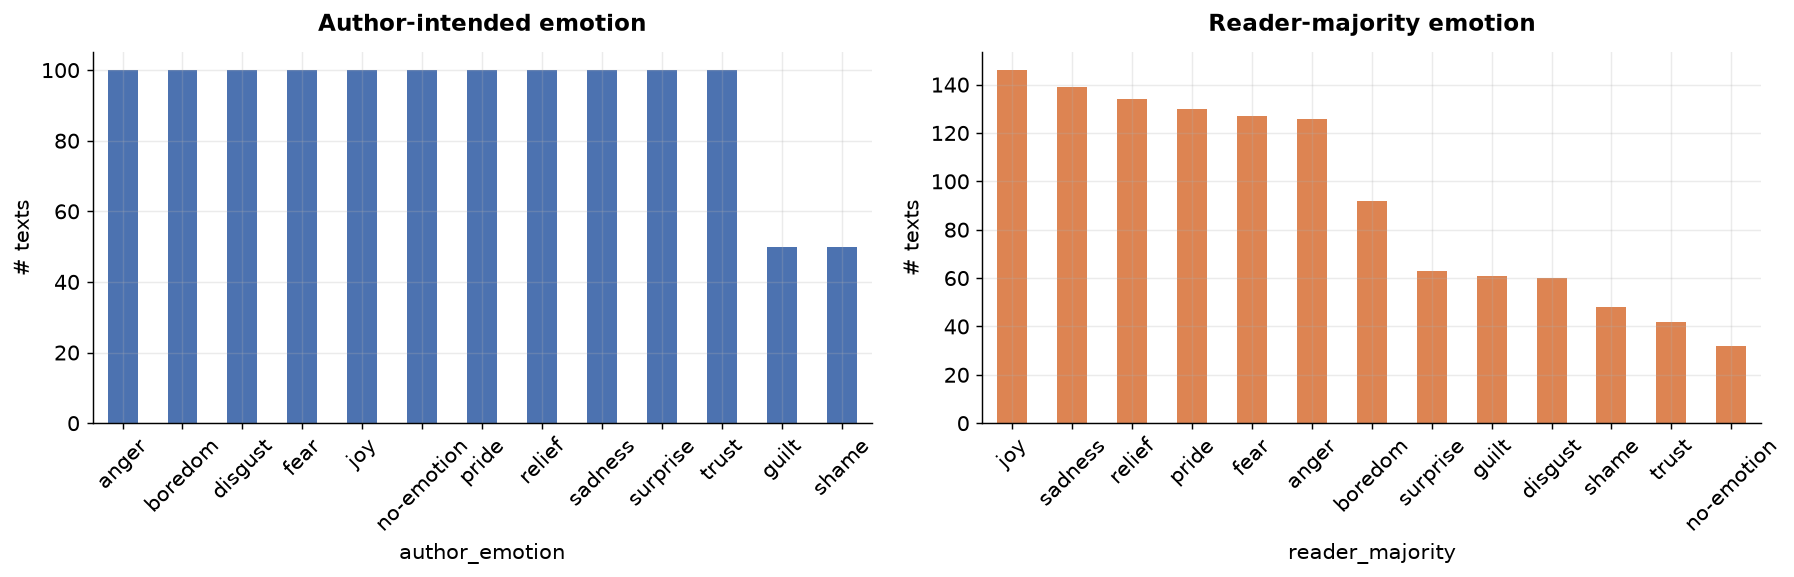

In [3]:
ac = pd.read_csv(BASE / 'ambiguity_classification_1200.csv')
ac['text_id'] = ac['text_id'].astype(int)
print(f"Annotated candidate pool: {len(ac):,} texts")
print(f"Columns: {list(ac.columns)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ac['author_emotion'].value_counts().plot.bar(ax=axes[0], color=COLORS['human'])
axes[0].set_title('Author-intended emotion', pad=12); axes[0].set_ylabel('# texts')
axes[0].tick_params(axis='x', rotation=45)
ac['reader_majority'].value_counts().plot.bar(ax=axes[1], color=COLORS['llm'])
axes[1].set_title('Reader-majority emotion', pad=12); axes[1].set_ylabel('# texts')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

wc = ac['text'].astype(str).str.split().str.len()
print(f"Text length: median {wc.median():.0f} words, IQR [{wc.quantile(.25):.0f}, {wc.quantile(.75):.0f}], max {wc.max()}")


**What the two charts show.** Left: what authors meant. Right: what most readers picked. The shapes
differ, so readers and authors often disagree before any persona is added. The corpus also
contains *boredom* and *no-emotion*, which are not among the 11 emotions; those texts are removed
in Step 0 below.

## 2. Measuring disagreement

Two numbers per text:
- **Does the reader majority match the author?** (`author_matches_readers`). A mismatch does not mean
  the text failed; readers may see another reasonable reading, which is what this thesis studies.
- **How many of the 5 readers chose the most popular emotion?** (`majority_share`; despite the name
  it is the share of the *top* emotion). Only five values are possible:
  - 0.2: all five chose different emotions;
  - 0.4: two readers agree (possibly a tie);
  - 0.6, 0.8, 1.0: 3, 4 or 5 readers agree. **3 of 5 is already a majority.**

The rule uses **0.8** (4 of 5 readers).

Author-reader agreement:
author_matches_readers
True     697
False    503
  -> readers recover the author's label for 58.1% of texts

Top-label share (stored as `majority_share`), 5 readers so only 5 values are attainable:


,n_texts,pct
majority_share,,
0.2,15,1.2
0.4,213,17.8
0.6,376,31.3
0.8,334,27.8
1.0,262,21.8


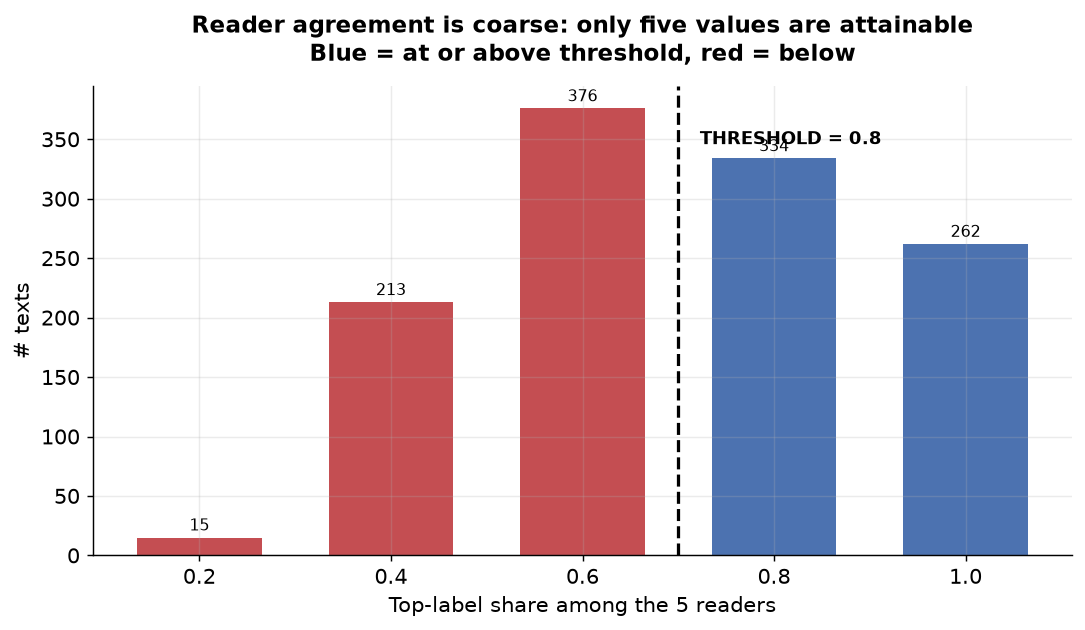

In [4]:
print("Author-reader agreement:")
print(ac['author_matches_readers'].value_counts().to_string())
print(f"  -> readers recover the author's label for {ac['author_matches_readers'].mean()*100:.1f}% of texts")
print()
print("Top-label share (stored as `majority_share`), 5 readers so only 5 values are attainable:")
share_tab = ac['majority_share'].value_counts().sort_index()
display(pd.DataFrame({'n_texts': share_tab, 'pct': (share_tab / len(ac) * 100).round(1)}))

fig, ax = plt.subplots(figsize=(8.5, 5))
x = share_tab.index.astype(float)
bars = ax.bar(x, share_tab.values, width=0.13,
              color=['#C44E52' if v < THRESHOLD else '#4C72B0' for v in x])
ax.axvline(THRESHOLD - 0.1, color='black', linestyle='--', lw=1.8)
ax.text(THRESHOLD - 0.09, share_tab.max()*0.92, f'  THRESHOLD = {THRESHOLD}', fontsize=10, fontweight='bold')
ax.set_xlabel('Top-label share among the 5 readers'); ax.set_ylabel('# texts')
ax.set_title('Reader agreement is coarse: only five values are attainable\nBlue = at or above threshold, red = below', pad=14)
for b, v in zip(bars, share_tab.values):
    ax.text(b.get_x()+b.get_width()/2, v+6, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()


### 2.1 Checking the stored numbers against the raw votes

The two numbers above come from a prepared file. Here they are rebuilt from the 6,000 raw reader
votes to check they are right. This covers all 1,200 candidate texts, not only the 300 sampled.

In [5]:
# Fail fast on missing, duplicate or incomplete candidate records before reconstruction.
assert ac['text_id'].is_unique, 'duplicate candidate text_id'
assert len(ac) == 1200, 'expected 1,200 candidate texts'
_candidate_votes = val[val['text_id'].isin(set(ac['text_id']))]
assert set(_candidate_votes['text_id']) == set(ac['text_id']), 'candidate vote coverage mismatch'
assert _candidate_votes['emotion'].notna().all(), 'missing candidate emotion label'
assert len(_candidate_votes) == 6000, 'expected 6,000 candidate votes'
assert _candidate_votes.groupby('text_id').size().eq(5).all(), 'expected five votes per candidate'
sample_ids_early = set(pd.read_csv(BASE / 'sampled_texts.csv')['text_id'].astype(int))

recon = []
for tid, g in val[val['text_id'].isin(set(ac['text_id']))].groupby('text_id'):
    vc = g['emotion'].value_counts()
    top = vc.max()
    winners = sorted(vc[vc == top].index)
    recon.append({'text_id': tid, 'recon_share': top / len(g),
                  'n_top': len(winners), 'recon_winners': winners})
R = pd.DataFrame(recon).merge(
    ac[['text_id', 'reader_majority', 'majority_share', 'author_emotion', 'author_matches_readers']],
    on='text_id', how='inner', validate='one_to_one')
print(f"Reconstruction scope: {len(val[val['text_id'].isin(set(ac['text_id']))]):,} votes "
      f"across {len(R):,} candidate texts (5 readers each)")

assert len(R) == len(ac) and set(R['text_id']) == set(ac['text_id']), 'reconstruction lost candidates'

share_ok = bool(np.allclose(R['recon_share'], R['majority_share']))
print(f"majority_share reconstructs exactly from raw votes : {share_ok}")

uniq = R[R['n_top'] == 1]
maj_ok = bool((uniq['recon_winners'].str[0] == uniq['reader_majority']).all())
print(f"reader_majority matches where the top label is unique: {maj_ok}  (n={len(uniq)})")

tied = R[R['n_top'] > 1]
tie_ok = bool(tied.apply(lambda r: r['reader_majority'] in r['recon_winners'], axis=1).all())
print(f"where the top is TIED, reader_majority is one of the tied winners: {tie_ok}  (n={len(tied)})")
print()
print(f"-> {len(tied)} of {len(R)} texts have a tie at the top, so a tie-break was applied.")
print("   The file does not record which rule; what is verifiable is that the stored label is")
print("   always one of the tied winners.")
print()

# Which definition does author_matches_readers use?
R['in_top_set'] = R.apply(lambda r: r['author_emotion'] in r['recon_winners'], axis=1)
R['eq_chosen'] = R['author_emotion'] == R['reader_majority']
print("author_matches_readers is defined as ...")
print(f"   author label within the tied TOP SET      : {(R['in_top_set'] == R['author_matches_readers']).mean()*100:.1f}% agreement")
print(f"   author label == the single chosen majority: {(R['eq_chosen'] == R['author_matches_readers']).mean()*100:.1f}% agreement")
assert bool((R['eq_chosen'] == R['author_matches_readers']).all()),     'author_matches_readers is not equality against the chosen reader_majority'
print()
print("So the field compares the author's label against the single TIE-BROKEN label, not against")
print("the set of tied winners. On a tied text whose author label is among the winners but is not")
print("the one selected, it records False.")

assert share_ok, 'top-label shares do not match raw votes'
assert maj_ok, 'stored unique top label differs from raw votes'
assert tie_ok, 'stored tie-broken label is not a tied winner'


Reconstruction scope: 6,000 votes across 1,200 candidate texts (5 readers each)
majority_share reconstructs exactly from raw votes : True
reader_majority matches where the top label is unique: True  (n=1066)
where the top is TIED, reader_majority is one of the tied winners: True  (n=134)

-> 134 of 1200 texts have a tie at the top, so a tie-break was applied.
   The file does not record which rule; what is verifiable is that the stored label is
   always one of the tied winners.

author_matches_readers is defined as ...
   author label within the tied TOP SET      : 96.3% agreement
   author label == the single chosen majority: 100.0% agreement

So the field compares the author's label against the single TIE-BROKEN label, not against
the set of tied winners. On a tied text whose author label is among the winners but is not
the one selected, it records False.


**Can the tie-break change anything?** For 134 texts the top was a tie, and the file picked one of
the tied emotions without recording how.
- It **cannot** change which texts count as unambiguous: 4 or 5 of 5 readers agreeing can never be
  a tie.
- It **can** change whether a text is eligible at all: in a tie between, say, anger and boredom,
  picking boredom removes the text. The next cell counts those texts and checks that none of them
  is in the final sample.

In [6]:
# Which texts, if any, have eligibility that hinges on the tie-break?
ALLOWED = set(CATEGORY_EMOTIONS)
crit = R[(R['n_top'] > 1)
         & R['recon_winners'].apply(lambda w: bool(set(w) & ALLOWED) and bool(set(w) & OFF_LABELS))
         & R['author_emotion'].isin(ALLOWED)].copy()
crit['retained'] = ~crit['reader_majority'].isin(OFF_LABELS)
crit['in_sample'] = crit['text_id'].isin(sample_ids_early)

print(f"Candidate texts whose ELIGIBILITY hinges on the tie-break: {len(crit)}")
print(f"   retained, because an allowed emotion was selected : {int(crit['retained'].sum())}")
print(f"   excluded, because an off-label emotion was selected: {int((~crit['retained']).sum())}")
print()
print(f"How many of these reached the final 300-text sample?   {int(crit['in_sample'].sum())}")
print()
print(f"Top-label shares among them: {sorted(crit['majority_share'].unique())}")
print("All sit at or below 0.4, so none could ever have met the 0.8 unambiguous threshold -- had")
print("any been retained and sampled, it could only have entered an AMBIGUOUS pool.")
print()
if len(crit):
    display(crit[['text_id', 'recon_winners', 'reader_majority', 'author_emotion',
                  'majority_share', 'retained', 'in_sample']])
assert not crit['in_sample'].any(), (
    'a text with tie-break-dependent eligibility entered the sample; its effect must be documented')
print("No text with tie-break-dependent eligibility entered the analysed sample, so the 300 texts")
print("used in Parts 1 and 2 are unaffected. The candidate POOL was affected, by at most the count")
print("above, which is recorded here rather than claimed to be immaterial.")


Candidate texts whose ELIGIBILITY hinges on the tie-break: 14
   retained, because an allowed emotion was selected : 6
   excluded, because an off-label emotion was selected: 8

How many of these reached the final 300-text sample?   0

Top-label shares among them: [np.float64(0.2), np.float64(0.4)]
All sit at or below 0.4, so none could ever have met the 0.8 unambiguous threshold -- had
any been retained and sampled, it could only have entered an AMBIGUOUS pool.

No text with tie-break-dependent eligibility entered the analysed sample, so the 300 texts
used in Parts 1 and 2 are unaffected. The candidate POOL was affected, by at most the count
above, which is recorded here rather than claimed to be immaterial.


,text_id,recon_winners,reader_majority,author_emotion,majority_share,retained,in_sample
14,89,"[fear, joy, no-emotion, relief, sadness]",no-emotion,relief,0.2,False,False
66,454,"[anger, boredom]",boredom,anger,0.4,False,False
100,689,"[anger, no-emotion]",anger,anger,0.4,True,False
115,764,"[boredom, pride]",boredom,fear,0.4,False,False
215,3325,"[no-emotion, sadness, shame, surprise, trust]",trust,disgust,0.2,True,False
274,3605,"[joy, no-emotion, pride, relief, surprise]",joy,joy,0.2,True,False
521,5774,"[fear, no-emotion]",no-emotion,fear,0.4,False,False
733,31143,"[boredom, fear]",boredom,shame,0.4,False,False
810,41287,"[boredom, no-emotion, relief, sadness, surprise]",boredom,relief,0.2,False,False
892,51017,"[disgust, guilt, joy, no-emotion, shame]",joy,guilt,0.2,True,False


**Key point.** Most texts do have a majority (usually 3 of 5), but only about one text in five is
unanimous, and some have no majority at all. Some disagreement is normal, which is why the later
notebooks keep every vote instead of one winning label.

## 3. The grouping rule

Applied in this order:
- **Step 0:** drop texts whose author label or reader-majority label is *boredom* or *no-emotion*.
- **Step 1:** **Unambiguous** if at least 4 of 5 readers agree *and* they agree with the author.
- **Step 2:** for the rest, two personas were tried in a pilot. Different emotions →
  **Author-relevant**; the same → **Author-independent**.

**Why this order?** A text readers already agree on stays unambiguous even if some persona could
flip it. That keeps the control group clean. It does not remove one limitation: the split between
the two ambiguous groups comes entirely from the pilot persona test, so H3 later asks whether that
pilot grouping predicts new data (a *transfer* test).

In [7]:
def classify(full, threshold=THRESHOLD):
    off = full['reader_majority'].isin(OFF_LABELS) | full['author_emotion'].isin(OFF_LABELS)
    pool = pd.Series(None, index=full.index, dtype=object)
    not_off = ~off
    is_unamb = not_off & (full['majority_share'] >= threshold) & (full['author_matches_readers'] == True)
    pool.loc[is_unamb] = 'Unambiguous'
    remaining = not_off & ~is_unamb
    flip_true = remaining & (full['flip'] == True)
    pool.loc[flip_true] = 'Author-Relevant Ambiguous'
    pool.loc[remaining & ~flip_true] = 'Author-Independent Ambiguous'
    return pool

ac['pool'] = classify(ac)
n_off = ac['pool'].isna().sum()
print(f"Step 0: {n_off} texts dropped as off-label ({sorted(OFF_LABELS)})")
print()
print("Candidate pool sizes after classification:")
counts = ac['pool'].value_counts().reindex(CATEGORY_LABELS)
display(pd.DataFrame({'n_candidates': counts, 'pct_of_eligible': (counts/counts.sum()*100).round(1)}))
print(f"Total eligible: {int(counts.sum())} of {len(ac)}")
print()
# The 1,200-text file also carries a `new_classification` column. It is HISTORICAL: it predates
# both the off-label exclusion and the threshold-first ordering, so it does not agree with the
# rule above. Quantified here rather than left as a silent discrepancy for a reader to trip over.
_cmp = pd.DataFrame({'rule': ac['pool'].fillna('OFF'),
                     'stored': ac['new_classification'].fillna('OFF')})
_dis = _cmp[_cmp['rule'] != _cmp['stored']]
print(f"Rows where the current rule differs from the file's stored `new_classification` column: {len(_dis)}")
display(_dis.groupby(['stored', 'rule']).size().to_frame('n'))
print("That column is a HISTORICAL artefact predating the off-label exclusion and the")
print("threshold-first ordering. It is NOT used by this pipeline: the authoritative category for")
print("every sampled text is `sampled_texts.csv.classification`, verified against the rule below.")


Step 0: 215 texts dropped as off-label (['boredom', 'no-emotion'])

Candidate pool sizes after classification:
Total eligible: 985 of 1200

Rows where the current rule differs from the file's stored `new_classification` column: 352
That column is a HISTORICAL artefact predating the off-label exclusion and the
threshold-first ordering. It is NOT used by this pipeline: the authoritative category for
every sampled text is `sampled_texts.csv.classification`, verified against the rule below.


,n_candidates,pct_of_eligible
pool,,
Unambiguous,384,39.0
Author-Independent Ambiguous,361,36.6
Author-Relevant Ambiguous,240,24.4


n
stored                       rule                            
Author-Independent Ambiguous Author-Relevant Ambiguous     40
                             OFF                           96
Author-Relevant Ambiguous    Author-Independent Ambiguous  46
                             OFF                           86
                             Unambiguous                   51
Unambiguous                  OFF                           33

### 3.1 What Step 0 does not remove

Step 0 looks at two labels per text (the author's and the reader majority), not at every single
reader vote. So a sampled text can still contain a stray *no-emotion* vote. The next cell counts
them; they are left out when vote shares are built.

In [8]:
EMO11 = set(CATEGORY_EMOTIONS)
sample_ids = set(pd.read_csv(BASE / 'sampled_texts.csv')['text_id'].astype(int))
sv = val[val['text_id'].isin(sample_ids)]
off_votes = sv[~sv['emotion'].isin(EMO11)]

print(f"Reader votes across the 300 sampled texts : {len(sv):,}")
print(f"Votes OUTSIDE the eleven-emotion set      : {len(off_votes)}"
      f"  ({len(off_votes)/len(sv)*100:.2f}%), across {off_votes['text_id'].nunique()} texts")
print(f"Breakdown: {off_votes['emotion'].value_counts().to_dict()}")
print()
print("These texts are legitimately in the sample: neither their author label nor their selected")
print("reader-majority label is off-inventory. What carries through is that a handful of the")
print("underlying reader votes are.")
print()
print("Consequence for Parts 1 and 2: such votes are EXCLUDED when the original-corpus vectors are")
print("built, so those vectors rest on fewer than five votes for the affected texts. That is why")
print("the vector construction tracks n per vector rather than assuming five throughout.")
retained_all_five = sv.groupby('text_id').apply(
    lambda g: bool(g['emotion'].isin(EMO11).all()), include_groups=False)
print(f"\nSampled texts retaining all five in-inventory votes: {int(retained_all_five.sum())} of 300")


Reader votes across the 300 sampled texts : 1,500
Votes OUTSIDE the eleven-emotion set      : 27  (1.80%), across 25 texts
Breakdown: {'no-emotion': 24, 'boredom': 3}

These texts are legitimately in the sample: neither their author label nor their selected
reader-majority label is off-inventory. What carries through is that a handful of the
underlying reader votes are.

Consequence for Parts 1 and 2: such votes are EXCLUDED when the original-corpus vectors are
built, so those vectors rest on fewer than five votes for the affected texts. That is why
the vector construction tracks n per vector rather than assuming five throughout.

Sampled texts retaining all five in-inventory votes: 275 of 300


### 3.2 What if the threshold were different?

0.6 = 3 of 5 readers, 0.8 = 4 of 5 (used), 1.0 = all 5. The table checks that each option still
leaves at least 100 texts per group. This shows availability; it does not prove 0.8 is the best
possible choice.

At 0.6 the unambiguous pool absorbs texts where only three of five readers agreed, which
weakens the control category the design depends on. At 1.0 it admits only unanimous texts.
Every setting shown leaves at least 100 candidates per pool, so 0.8 is not forced by
availability -- it is the chosen four-of-five agreement rule, not a statistically optimized threshold.


,threshold,Unambiguous,Author-Independent Ambiguous,Author-Relevant Ambiguous,enough_for_100_each
0,0.6,541,252,192,True
1,0.8,384,361,240,True
2,1.0,182,518,285,True


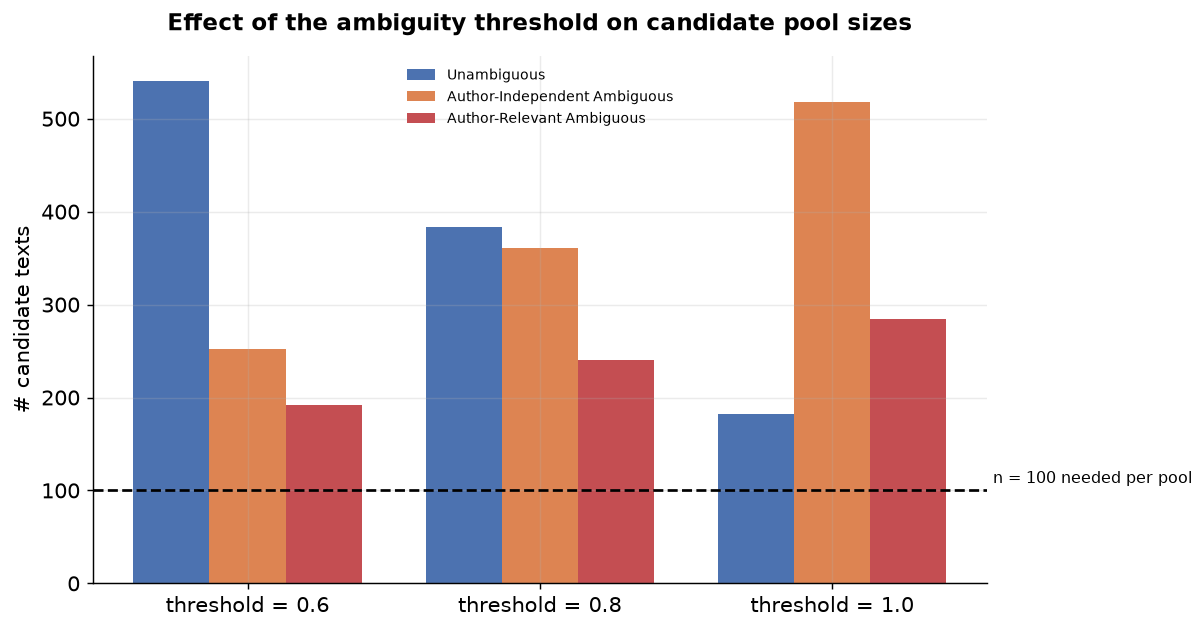

In [9]:
rows = []
for t in (0.6, 0.8, 1.0):
    p = classify(ac, threshold=t)
    c = p.value_counts().reindex(CATEGORY_LABELS).fillna(0).astype(int)
    rows.append({'threshold': t, **{lab: c[lab] for lab in CATEGORY_LABELS},
                 'enough_for_100_each': bool((c >= 100).all())})
sens = pd.DataFrame(rows)
display(sens)

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(sens)); w = 0.26
for i, lab in enumerate(CATEGORY_LABELS):
    ax.bar(x + (i-1)*w, sens[lab], width=w, label=lab, color=COLORS[lab])
ax.axhline(100, color='black', linestyle='--', lw=1.5)
ax.text(len(sens)-0.45, 108, 'n = 100 needed per pool', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'threshold = {t}' for t in sens['threshold']])
ax.set_ylabel('# candidate texts'); ax.legend(fontsize=8)
ax.set_title('Effect of the ambiguity threshold on candidate pool sizes', pad=14)
plt.tight_layout(); plt.show()

print("At 0.6 the unambiguous pool absorbs texts where only three of five readers agreed, which")
print("weakens the control category the design depends on. At 1.0 it admits only unanimous texts.")
print(f"Every setting shown leaves at least 100 candidates per pool, so {THRESHOLD} is not forced by")
print("availability -- it is the chosen four-of-five agreement rule, not a statistically optimized threshold.")


## 4. The final sample

The sample was **not** made by one fresh random draw. An earlier sample was kept and updated:
1. keep the existing `sampled_texts.csv`;
2. re-classify every text with the rule above;
3. if a group has more than 100 texts, drop the extra ones (fixed seed 42);
4. fill any gap with unused eligible texts, never using the 3 texts reserved as prompt examples;
5. check: 300 texts, 100 per group, no duplicates.

So the **rule** is reproducible, but the exact list of texts depends on the earlier sample.
`sampled_texts.csv` is the official record of which texts were used.

In [10]:
sampled = pd.read_csv(BASE / 'sampled_texts.csv')
sampled['text_id'] = sampled['text_id'].astype(int)

print(f"Final sample: {len(sampled)} texts")
final_counts = sampled['classification'].value_counts().reindex(CATEGORY_LABELS)
display(final_counts.to_frame('n_texts'))

checks = []
checks.append(('exactly 300 texts', len(sampled) == 300))
checks.append(('balanced at 100 per category', bool((final_counts == 100).all())))
checks.append(('no reserved example text sampled', not set(sampled['text_id']) & EXAMPLE_IDS))
checks.append(('no duplicate text_id', sampled['text_id'].duplicated().sum() == 0))
merged_chk = sampled.merge(ac[['text_id', 'pool']], on='text_id', how='left', validate='one_to_one')
checks.append(('every sampled text has an eligible pool', merged_chk['pool'].notna().all()))
checks.append(('sample classification matches the rule',
               bool((merged_chk['classification'] == merged_chk['pool']).all())))
off_in_sample = merged_chk['text_id'].isin(
    ac.loc[ac['pool'].isna(), 'text_id']).sum()
checks.append(('no off-label text in the sample', off_in_sample == 0))

# Candidate-file integrity, checked before anything is concluded from it.
assert ac['text_id'].is_unique, 'duplicate text_id in the candidate file'
assert sampled['text_id'].is_unique, 'duplicate text_id in the sample'

for name, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
print()
print(f"{sum(ok for _, ok in checks)}/{len(checks)} checks passed")

# These are assertions, not advisory prints: a FAIL must stop the notebook rather than leave a
# red line in the output for a reader to notice or miss.
failed = [name for name, ok in checks if not ok]
assert not failed, f"sample verification failed: {failed}"
print("All sample checks are assertions -- execution stops here on any failure.")


Final sample: 300 texts
[PASS] exactly 300 texts
[PASS] balanced at 100 per category
[PASS] no reserved example text sampled
[PASS] no duplicate text_id
[PASS] every sampled text has an eligible pool
[PASS] sample classification matches the rule
[PASS] no off-label text in the sample

7/7 checks passed
All sample checks are assertions -- execution stops here on any failure.


,n_texts
classification,
Unambiguous,100
Author-Independent Ambiguous,100
Author-Relevant Ambiguous,100


Sampling fractions differ by pool because the pools differ in size. This is intended: the
design prioritises equal n per category over proportional representation of the corpus, so
that category comparisons are not confounded with unequal sample size.


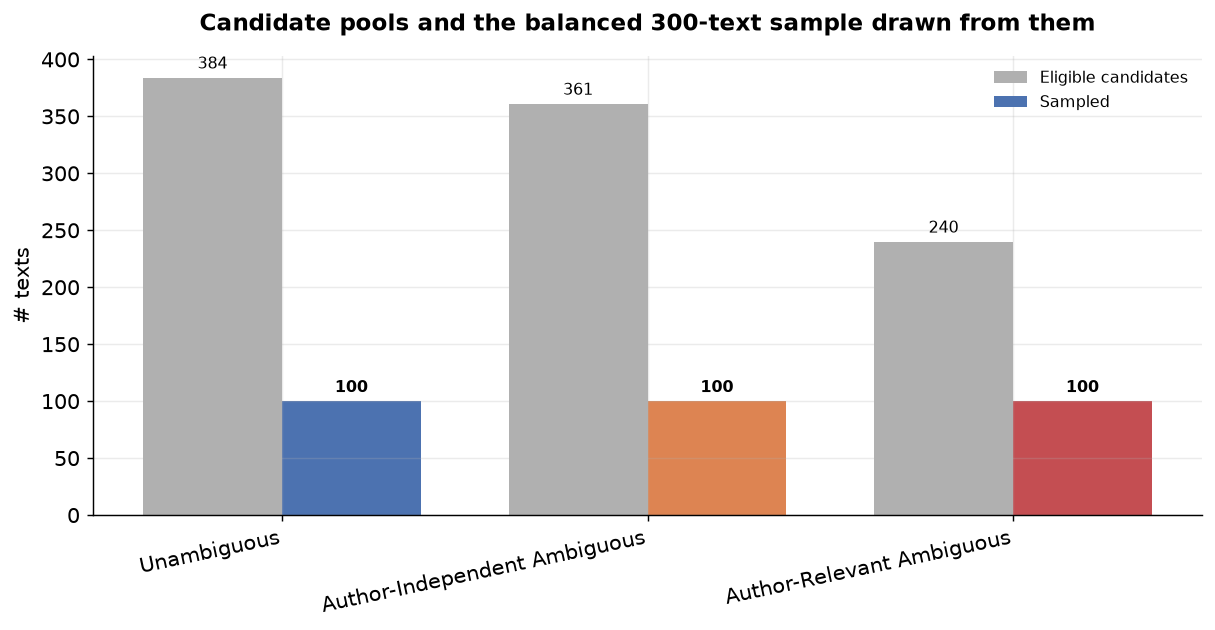

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(CATEGORY_LABELS)); w = 0.38
cand = ac['pool'].value_counts().reindex(CATEGORY_LABELS)
ax.bar(x - w/2, cand.values, width=w, label='Eligible candidates', color='#B0B0B0')
ax.bar(x + w/2, final_counts.values, width=w, label='Sampled', color=[COLORS[l] for l in CATEGORY_LABELS])
for i, (c, s) in enumerate(zip(cand.values, final_counts.values)):
    ax.text(i - w/2, c + 8, str(c), ha='center', fontsize=9)
    ax.text(i + w/2, s + 8, str(s), ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CATEGORY_LABELS, rotation=12, ha='right')
ax.set_ylabel('# texts'); ax.legend(fontsize=9)
ax.set_title('Candidate pools and the balanced 300-text sample drawn from them', pad=14)
plt.tight_layout(); plt.show()

print("Sampling fractions differ by pool because the pools differ in size. This is intended: the")
print("design prioritises equal n per category over proportional representation of the corpus, so")
print("that category comparisons are not confounded with unequal sample size.")


### 4.1 What the persona pairs look like

Each text has two personas and a reason for the pairing. The pilot emotion under each persona, and
whether the two differ (`flip`), decided Step 2.

In [12]:
cols = ['text_id', 'classification', 'author_emotion', 'reader_majority', 'majority_share',
        'persona_a', 'judge_a', 'persona_b', 'judge_b', 'flip']
ex = sampled[sampled['classification'] == CATEGORY_LABELS[2]].head(3)[cols]
for _, r in ex.iterrows():
    print(f"text {r['text_id']}  [{r['classification']}]")
    print(f"  author said: {r['author_emotion']}   readers said: {r['reader_majority']} ({r['majority_share']})")
    print(f"  persona A: {r['persona_a']}  -> judged {r['judge_a']}")
    print(f"  persona B: {r['persona_b']}  -> judged {r['judge_b']}")
    print(f"  flip = {r['flip']}")
    print()

print("Flip rate within the final sample, by category:")
display((sampled.groupby('classification')['flip'].mean() * 100).reindex(CATEGORY_LABELS).round(1).to_frame('flip_rate_pct'))


text 378  [Author-Relevant Ambiguous]
  author said: anger   readers said: disgust (0.4)
  persona A: an adult child who has been repeatedly gaslit by this parent for years  -> judged anger
  persona B: someone estranged from their mother, cautiously trying to reconnect  -> judged sadness
  flip = True

text 441  [Author-Relevant Ambiguous]
  author said: anger   readers said: anger (0.6)
  persona A: a woman recently discovering the infidelity, blindsided  -> judged sadness
  persona B: a woman who had long suspected her boyfriend was unfaithful and just got confirmation  -> judged anger
  flip = True

text 6337  [Author-Relevant Ambiguous]
  author said: fear   readers said: fear (0.6)
  persona A: a horror fan who loves haunted house experiences  -> judged joy
  persona B: someone dragged along by friends who hates being scared  -> judged fear
  flip = True

Flip rate within the final sample, by category:


,flip_rate_pct
classification,
Unambiguous,20.0
Author-Independent Ambiguous,0.0
Author-Relevant Ambiguous,100.0


**Keep in mind for H3.** Author-relevant texts have a flip rate of 100% because that is how they
were defined; author-independent texts have 0%. H3 asks whether this pilot grouping predicts
effects in the *new* human and model data. That is a fair question, but it is a transfer test, not
an independent discovery.

## 5. Summary

| Setting | Value |
|---|---|
| Unambiguous threshold | at least 4 of 5 readers agree **and** match the author (0.8) |
| Order of the rule | threshold first, then the pilot flip test |
| Excluded labels | boredom, no-emotion |
| Reserved prompt examples | 3 texts, never sampled |
| Random seed | 42 |
| Final sample | 300 texts, 100 per group (`sampled_texts.csv`) |

Notebooks 1 and 2 take `sampled_texts.csv` as given.